In [6]:
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import datetime
from math import radians, sin, cos, asin, sqrt
import os

oxts_path = 'C:/Users/Andrei/PycharmProjects/HW_Adv_ROB/data/2011_09_26_drive_0001_sync/oxts'

data_dir = f"{oxts_path}/data"
timestamps_file = f"{oxts_path}/timestamps.txt"

print("Путь к данным:", oxts_path)

Путь к данным: C:/Users/Andrei/PycharmProjects/HW_Adv_ROB/data/2011_09_26_drive_0001_sync/oxts


**Чтение timestamps**

In [9]:
with open(timestamps_file, encoding='utf-8') as f:
    lines = [line.strip() for line in f if line.strip()]

# Парсинг с защитой от лишних чисел
timestamps = []
for line in lines:
    # Берём всё до последнего пробела
    if ' ' in line:
        timestamp_str = line.rsplit(' ', 1)[0]
    else:
        timestamp_str = line

    # Основной парсинг
    try:
        dt_obj = datetime.strptime(timestamp_str, '%Y-%m-%d %H:%M:%S.%f')
    except ValueError:
        # Запасной вариант через regex
        match = re.search(r'(\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2}\.\d{1,9})', line)
        if match:
            ts_str = match.group(1)
            # Приводим микросекунды к 6 цифрам
            if '.' in ts_str:
                date_part, frac_part = ts_str.split('.')
                frac_part = frac_part[:6].ljust(6, '0')
                ts_str = date_part + '.' + frac_part
            dt_obj = datetime.strptime(ts_str, '%Y-%m-%d %H:%M:%S.%f')
        else:
            print("Не удалось распарсить строку:", line)
            continue

    timestamps.append(dt_obj)

# Превращаем в секунды от начала
time_sec = np.array([(t - timestamps[0]).total_seconds() for t in timestamps])
dt = np.diff(time_sec, prepend=0.0)
dt = np.maximum(dt, 0.01)

print(f"Успешно загружено {len(time_sec)} таймстампов")
print(f"Длительность записи: {time_sec[-1]:.2f} секунд")

Успешно загружено 108 таймстампов
Длительность записи: 11.04 секунд


**Чтение oxts данных (lat, lon, af)**

In [10]:
def read_oxts_file(filename):
    with open(filename) as f:
        line = f.readline().strip()
    values = [float(x) for x in line.split()]
    lat = values[0]      # latitude
    lon = values[1]      # longitude
    af  = values[14]     # forward acceleration
    return lat, lon, af

files = sorted([f for f in os.listdir(data_dir) if f.endswith('.txt')])
import os
oxts_data = [read_oxts_file(os.path.join(data_dir, f)) for f in files]

lat = np.array([d[0] for d in oxts_data])
lon = np.array([d[1] for d in oxts_data])
u   = np.array([d[2] for d in oxts_data])

print(f"af (ускорение) min/max: {u.min():.3f} / {u.max():.3f} м/с²")

af (ускорение) min/max: -1.586 / -0.251 м/с²


**Расчет дистанции по GPS**

In [11]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return R * c

start_lat, start_lon = lat[0], lon[0]
gps_dist = [0.0]
for i in range(1, len(lat)):
    dist = haversine(start_lat, start_lon, lat[i], lon[i])
    gps_dist.append(dist)

z = np.array(gps_dist)

print(f"Финальная дистанция по GPS: {gps_dist[-1]:.1f} метров")

Финальная дистанция по GPS: 106.7 метров


**Оценка шумов**

In [12]:
static_start, static_end = 0, 50
std_acc = np.std(u[static_start:static_end])
print(f"std_acc (шум процесса): {std_acc:.4f} м/с²")

std_meas = 3.0
print(f"std_meas (шум GPS): {std_meas} м")

std_acc (шум процесса): 0.2315 м/с²
std_meas (шум GPS): 3.0 м


**Фильтр Калмана**

In [13]:
def run_kalman_filter(z, u, dt, std_acc, std_meas):
    n = len(z)
    x = np.zeros((n, 2))      # [Позиция, скорость]
    P = np.zeros((n, 2, 2))

    x[0] = [0.0, 0.0]
    P[0] = np.eye(2) * 100

    for i in range(1, n):
        dti = dt[i]
        F = np.array([[1, dti], [0, 1]])
        B = np.array([0.5 * dti**2, dti])
        Q = (std_acc**2) * np.array([[dti**4/4, dti**3/2],
                                     [dti**3/2,   dti**2]])

        # Предсказание
        x_pred = F @ x[i-1] + B * u[i]
        P_pred = F @ P[i-1] @ F.T + Q

        # Обновление
        H = np.array([[1, 0]])
        R = std_meas**2
        y = z[i] - H @ x_pred
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T / S

        x[i] = x_pred + (K.flatten() * y)
        P[i] = (np.eye(2) - K @ H) @ P_pred

    return x[:, 0]

kf_distance = run_kalman_filter(z, u, dt, std_acc, std_meas)

**Результаты измерений**

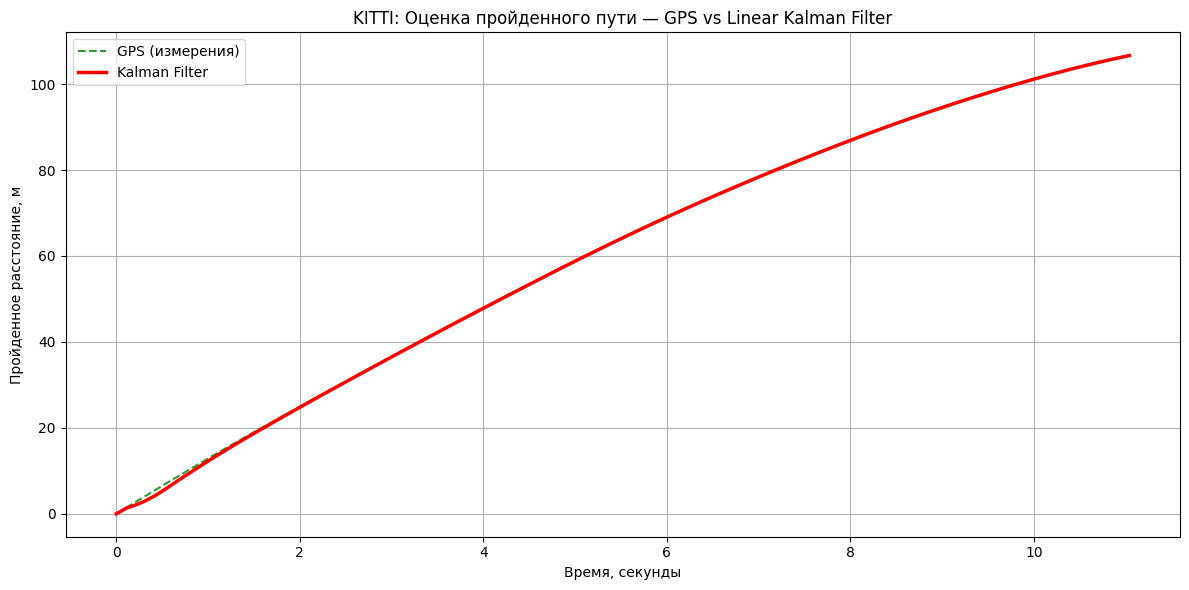

Финальная дистанция GPS: 106.7 м
Финальная оценка KF:    106.7 м


In [15]:
plt.figure(figsize=(12, 6))
plt.plot(time_sec, z, 'g--', label='GPS (измерения)', alpha=0.8)
plt.plot(time_sec, kf_distance, 'r-', linewidth=2.5, label='Kalman Filter')
plt.xlabel('Время, секунды')
plt.ylabel('Пройденное расстояние, м')
plt.title('KITTI: Оценка пройденного пути — GPS vs Linear Kalman Filter')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Финальная дистанция GPS: {z[-1]:.1f} м")
print(f"Финальная оценка KF:    {kf_distance[-1]:.1f} м")